In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

In [3]:

df = pd.read_csv("data/Mall_Customers.csv")


In [5]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (200, 5)

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate Rows:
0


In [7]:
features = [
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

X = df[features].copy()

print("Selected Features:", features)
print("Shape:", X.shape)

Selected Features: ['Annual Income (k$)', 'Spending Score (1-100)']
Shape: (200, 2)


In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=features
)

X_scaled_df.head()

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


In [11]:
X_scaled_df.describe()

,Annual Income (k$),Spending Score (1-100)
count,2.000000e+02,2.000000e+02
mean,-2.131628e-16,-1.465494e-16
std,1.002509e+00,1.002509e+00
min,-1.738999e+00,-1.910021e+00
25%,-7.275093e-01,-5.997931e-01
50%,3.587926e-02,-7.764312e-03
75%,6.656748e-01,8.851316e-01
max,2.917671e+00,1.894492e+00


In [13]:
neighbors = NearestNeighbors(
    n_neighbors=5
)

neighbors.fit(X_scaled)

distances, indices = neighbors.kneighbors(X_scaled)

In [15]:
k_distances = distances[:, 4]

k_distances = np.sort(k_distances)

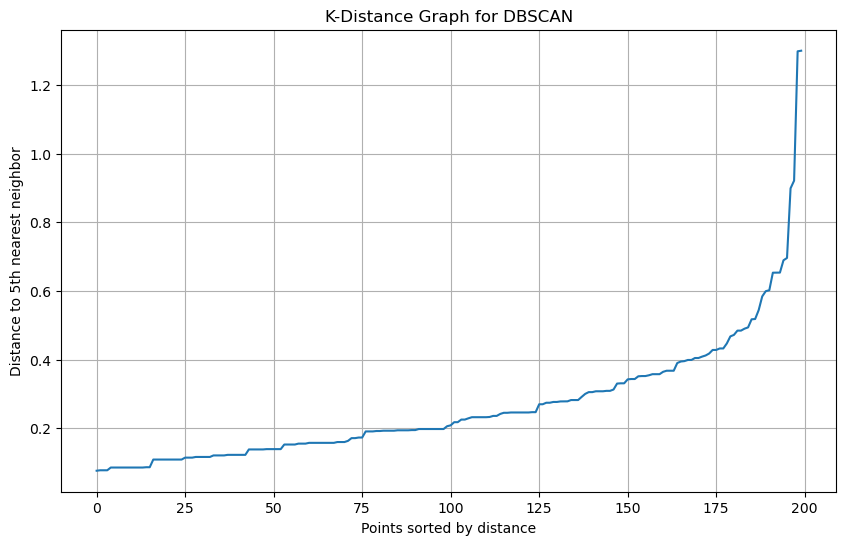

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_distances
)

plt.title("K-Distance Graph for DBSCAN")
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance to 5th nearest neighbor")

plt.grid(True)

plt.show()

In [19]:
eps_values = [
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60
]

In [21]:
min_samples = 5

In [23]:
dbscan_results = []

for eps in eps_values:
    
    model = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )
    
    labels = model.fit_predict(X_scaled)
    
    n_clusters = len(
        set(labels)
    ) - (1 if -1 in labels else 0)
    
    n_noise = np.sum(
        labels == -1
    )
    
    if n_clusters >= 2:
        score = silhouette_score(
            X_scaled[labels != -1],
            labels[labels != -1]
        )
    else:
        score = np.nan
    
    dbscan_results.append({
        "eps": eps,
        "clusters": n_clusters,
        "noise_points": n_noise,
        "silhouette_score": score
    })

In [25]:
dbscan_results_df = pd.DataFrame(
    dbscan_results
)

dbscan_results_df

,eps,clusters,noise_points,silhouette_score
0,0.20,7,77,0.585613
1,0.25,6,50,0.531657
2,0.30,7,35,0.524328
3,0.35,6,23,0.557746
4,0.40,4,15,0.478059
5,0.45,3,11,0.353641
6,0.50,2,8,0.387558
7,0.55,1,7,NaN
8,0.60,1,5,NaN


In [27]:
dbscan_results_df.sort_values(
    "silhouette_score",
    ascending=False
)

,eps,clusters,noise_points,silhouette_score
0,0.20,7,77,0.585613
3,0.35,6,23,0.557746
1,0.25,6,50,0.531657
2,0.30,7,35,0.524328
4,0.40,4,15,0.478059
6,0.50,2,8,0.387558
5,0.45,3,11,0.353641
7,0.55,1,7,NaN
8,0.60,1,5,NaN


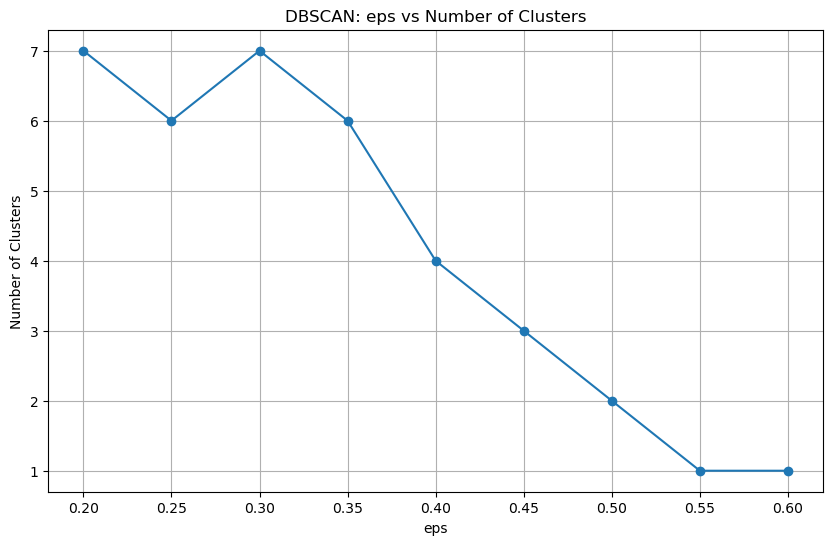

In [29]:
plt.figure(figsize=(10, 6))

plt.plot(
    dbscan_results_df["eps"],
    dbscan_results_df["clusters"],
    marker="o"
)

plt.title("DBSCAN: eps vs Number of Clusters")
plt.xlabel("eps")
plt.ylabel("Number of Clusters")

plt.grid(True)

plt.show()

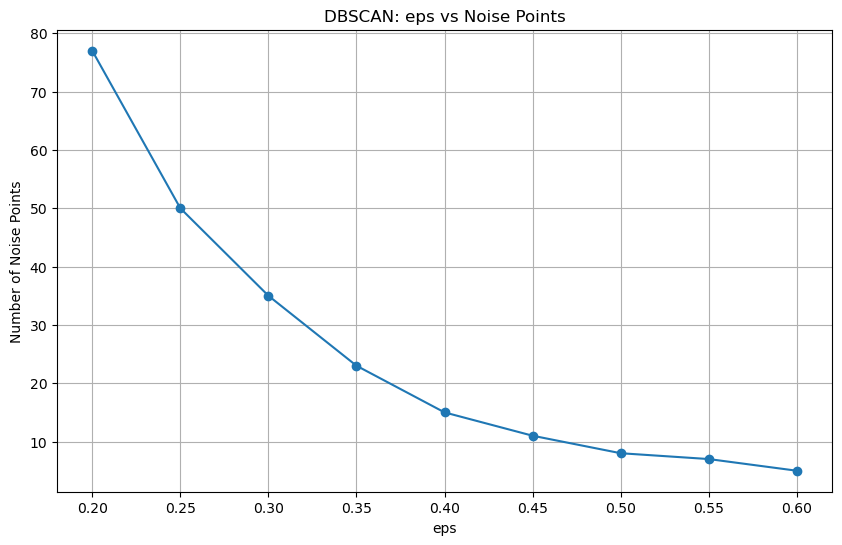

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(
    dbscan_results_df["eps"],
    dbscan_results_df["noise_points"],
    marker="o"
)

plt.title("DBSCAN: eps vs Noise Points")
plt.xlabel("eps")
plt.ylabel("Number of Noise Points")

plt.grid(True)

plt.show()

In [33]:
valid_results = dbscan_results_df.dropna(
    subset=["silhouette_score"]
)

best_dbscan_row = valid_results.loc[
    valid_results["silhouette_score"].idxmax()
]

print(
    "Best eps:",
    best_dbscan_row["eps"]
)

print(
    "Clusters:",
    int(best_dbscan_row["clusters"])
)

print(
    "Noise points:",
    int(best_dbscan_row["noise_points"])
)

print(
    "Silhouette Score:",
    round(
        best_dbscan_row["silhouette_score"],
        4
    )
)

Best eps: 0.2
Clusters: 7
Noise points: 77
Silhouette Score: 0.5856


In [35]:
dbscan_results_df

,eps,clusters,noise_points,silhouette_score
0,0.20,7,77,0.585613
1,0.25,6,50,0.531657
2,0.30,7,35,0.524328
3,0.35,6,23,0.557746
4,0.40,4,15,0.478059
5,0.45,3,11,0.353641
6,0.50,2,8,0.387558
7,0.55,1,7,NaN
8,0.60,1,5,NaN


In [37]:
dbscan_results_df.sort_values(
    "eps"
)

,eps,clusters,noise_points,silhouette_score
0,0.20,7,77,0.585613
1,0.25,6,50,0.531657
2,0.30,7,35,0.524328
3,0.35,6,23,0.557746
4,0.40,4,15,0.478059
5,0.45,3,11,0.353641
6,0.50,2,8,0.387558
7,0.55,1,7,NaN
8,0.60,1,5,NaN


In [39]:
dbscan_results_df[
    (dbscan_results_df["clusters"] >= 3) &
    (dbscan_results_df["clusters"] <= 8)
].sort_values(
    "silhouette_score",
    ascending=False
)

,eps,clusters,noise_points,silhouette_score
0,0.20,7,77,0.585613
3,0.35,6,23,0.557746
1,0.25,6,50,0.531657
2,0.30,7,35,0.524328
4,0.40,4,15,0.478059
5,0.45,3,11,0.353641


In [41]:
dbscan_results_df["noise_percentage"] = (
    dbscan_results_df["noise_points"] / len(df) * 100
).round(2)

dbscan_results_df

,eps,clusters,noise_points,silhouette_score,noise_percentage
0,0.20,7,77,0.585613,38.5
1,0.25,6,50,0.531657,25.0
2,0.30,7,35,0.524328,17.5
3,0.35,6,23,0.557746,11.5
4,0.40,4,15,0.478059,7.5
5,0.45,3,11,0.353641,5.5
6,0.50,2,8,0.387558,4.0
7,0.55,1,7,NaN,3.5
8,0.60,1,5,NaN,2.5


In [43]:
reasonable_dbscan = dbscan_results_df[
    (dbscan_results_df["clusters"] >= 3) &
    (dbscan_results_df["clusters"] <= 8) &
    (dbscan_results_df["noise_percentage"] <= 20)
].copy()

reasonable_dbscan.sort_values(
    "silhouette_score",
    ascending=False
)

,eps,clusters,noise_points,silhouette_score,noise_percentage
3,0.35,6,23,0.557746,11.5
2,0.30,7,35,0.524328,17.5
4,0.40,4,15,0.478059,7.5
5,0.45,3,11,0.353641,5.5


In [45]:
eps_values = np.arange(
    0.20,
    1.01,
    0.05
).round(2)

eps_values

array([0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55, 0.6 , 0.65, 0.7 ,
       0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

In [47]:
dbscan_results = []

for eps in eps_values:

    model = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = model.fit_predict(X_scaled)

    n_clusters = len(
        set(labels)
    ) - (1 if -1 in labels else 0)

    n_noise = np.sum(
        labels == -1
    )

    noise_percentage = (
        n_noise / len(df) * 100
    )

    non_noise_mask = labels != -1

    if (
        n_clusters >= 2
        and non_noise_mask.sum() > n_clusters
    ):
        score = silhouette_score(
            X_scaled[non_noise_mask],
            labels[non_noise_mask]
        )
    else:
        score = np.nan

    dbscan_results.append({
        "eps": eps,
        "clusters": n_clusters,
        "noise_points": n_noise,
        "noise_percentage": noise_percentage,
        "silhouette_score": score
    })

dbscan_results_df = pd.DataFrame(
    dbscan_results
)

dbscan_results_df

,eps,clusters,noise_points,noise_percentage,silhouette_score
0,0.20,7,77,38.5,0.585613
1,0.25,6,50,25.0,0.531657
2,0.30,7,35,17.5,0.524328
3,0.35,6,23,11.5,0.557746
4,0.40,4,15,7.5,0.478059
5,0.45,3,11,5.5,0.353641
6,0.50,2,8,4.0,0.387558
7,0.55,1,7,3.5,NaN
8,0.60,1,5,2.5,NaN
9,0.65,1,5,2.5,NaN


In [49]:
practical_candidates = dbscan_results_df[
    (dbscan_results_df["clusters"] >= 3) &
    (dbscan_results_df["clusters"] <= 8) &
    (dbscan_results_df["noise_percentage"] <= 20)
].sort_values(
    "silhouette_score",
    ascending=False
)

practical_candidates

,eps,clusters,noise_points,noise_percentage,silhouette_score
3,0.35,6,23,11.5,0.557746
2,0.30,7,35,17.5,0.524328
4,0.40,4,15,7.5,0.478059
5,0.45,3,11,5.5,0.353641


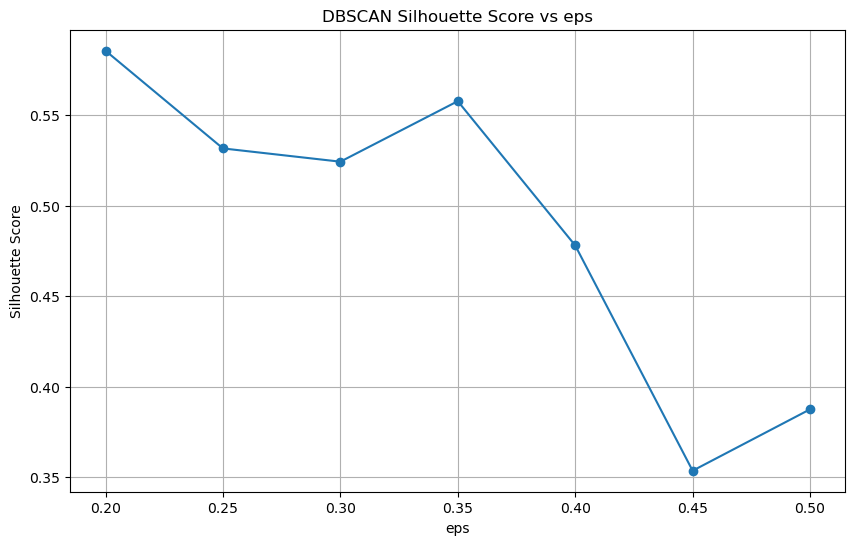

In [51]:
plt.figure(figsize=(10, 6))

plt.plot(
    dbscan_results_df["eps"],
    dbscan_results_df["silhouette_score"],
    marker="o"
)

plt.title("DBSCAN Silhouette Score vs eps")
plt.xlabel("eps")
plt.ylabel("Silhouette Score")

plt.grid(True)

plt.show()

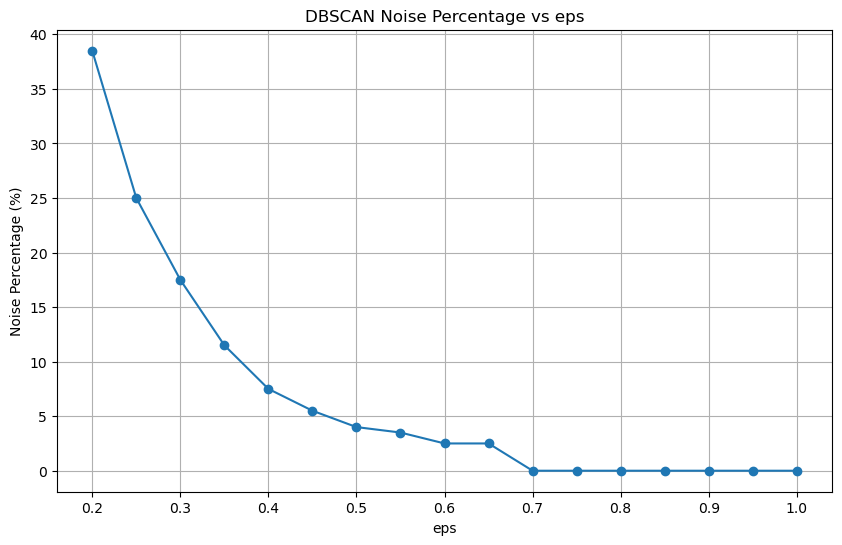

In [53]:
plt.figure(figsize=(10, 6))

plt.plot(
    dbscan_results_df["eps"],
    dbscan_results_df["noise_percentage"],
    marker="o"
)

plt.title("DBSCAN Noise Percentage vs eps")
plt.xlabel("eps")
plt.ylabel("Noise Percentage (%)")

plt.grid(True)

plt.show()

In [55]:
final_eps = 0.35
final_min_samples = 5

final_dbscan = DBSCAN(
    eps=final_eps,
    min_samples=final_min_samples
)

dbscan_labels = final_dbscan.fit_predict(X_scaled)

print("DBSCAN model trained.")

DBSCAN model trained.


In [57]:
np.unique(dbscan_labels)

array([-1,  0,  1,  2,  3,  4,  5])

In [59]:
dbscan_counts = pd.Series(
    dbscan_labels
).value_counts().sort_index()

dbscan_counts

-1    23
 0    16
 1    12
 2     7
 3    88
 4    31
 5    23
Name: count, dtype: int64

In [61]:
df["DBSCAN_Cluster"] = dbscan_labels

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),DBSCAN_Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,0
2,3,Female,20,16,6,1
3,4,Female,23,16,77,0
4,5,Female,31,17,40,2


In [63]:
noise_count = np.sum(
    dbscan_labels == -1
)

noise_percentage = (
    noise_count / len(df) * 100
)

print("Noise Customers:", noise_count)
print(
    "Noise Percentage:",
    round(noise_percentage, 2),
    "%"
)

Noise Customers: 23
Noise Percentage: 11.5 %


In [65]:
final_dbscan.core_sample_indices_

array([  1,   2,   3,   5,   6,   9,  10,  13,  14,  15,  16,  17,  18,
        20,  21,  22,  23,  24,  26,  28,  31,  35,  37,  40,  42,  43,
        46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,  57,  58,
        59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,  70,  71,
        72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,
        85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,
        98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110,
       111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123,
       125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137,
       138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150,
       151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163,
       165, 166, 170, 172, 173, 174, 176, 178, 179, 181])

In [67]:
core_mask = np.zeros(
    len(X_scaled),
    dtype=bool
)

core_mask[
    final_dbscan.core_sample_indices_
] = True

In [69]:
noise_mask = dbscan_labels == -1

border_mask = (
    ~core_mask
    & ~noise_mask
)

In [71]:
print(
    "Core Points:",
    core_mask.sum()
)

print(
    "Border Points:",
    border_mask.sum()
)

print(
    "Noise Points:",
    noise_mask.sum()
)

Core Points: 153
Border Points: 24
Noise Points: 23


In [73]:
print(
    core_mask.sum()
    + border_mask.sum()
    + noise_mask.sum()
)

200


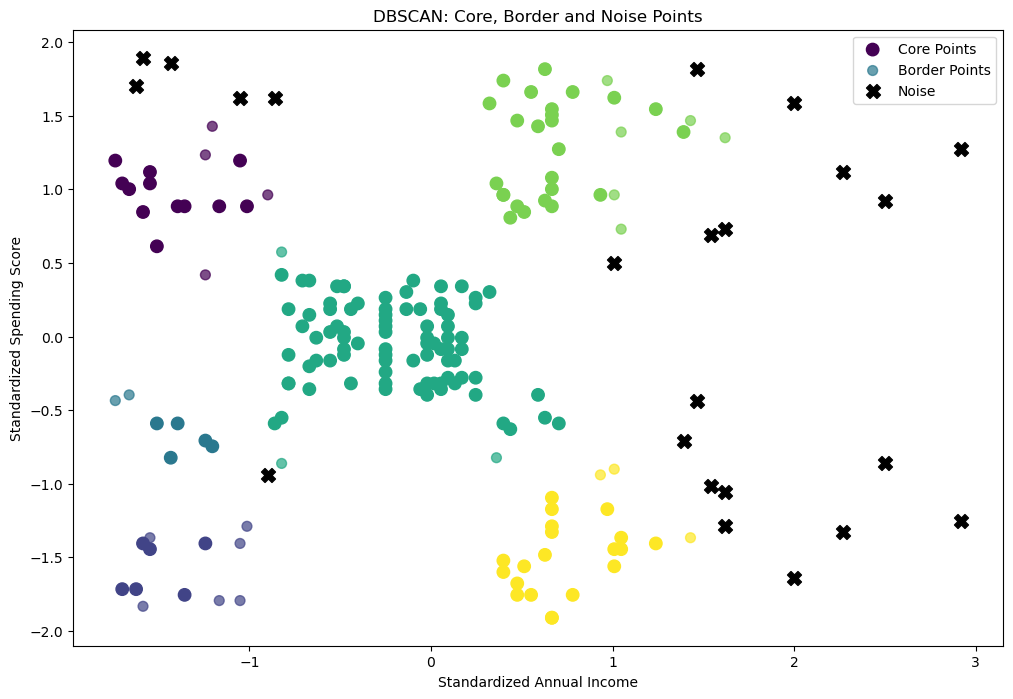

In [75]:
plt.figure(figsize=(12, 8))

plt.scatter(
    X_scaled[core_mask, 0],
    X_scaled[core_mask, 1],
    c=dbscan_labels[core_mask],
    s=80,
    label="Core Points"
)

plt.scatter(
    X_scaled[border_mask, 0],
    X_scaled[border_mask, 1],
    c=dbscan_labels[border_mask],
    s=50,
    marker="o",
    alpha=0.7,
    label="Border Points"
)

plt.scatter(
    X_scaled[noise_mask, 0],
    X_scaled[noise_mask, 1],
    c="black",
    s=100,
    marker="X",
    label="Noise"
)

plt.title("DBSCAN: Core, Border and Noise Points")
plt.xlabel("Standardized Annual Income")
plt.ylabel("Standardized Spending Score")

plt.legend()

plt.show()

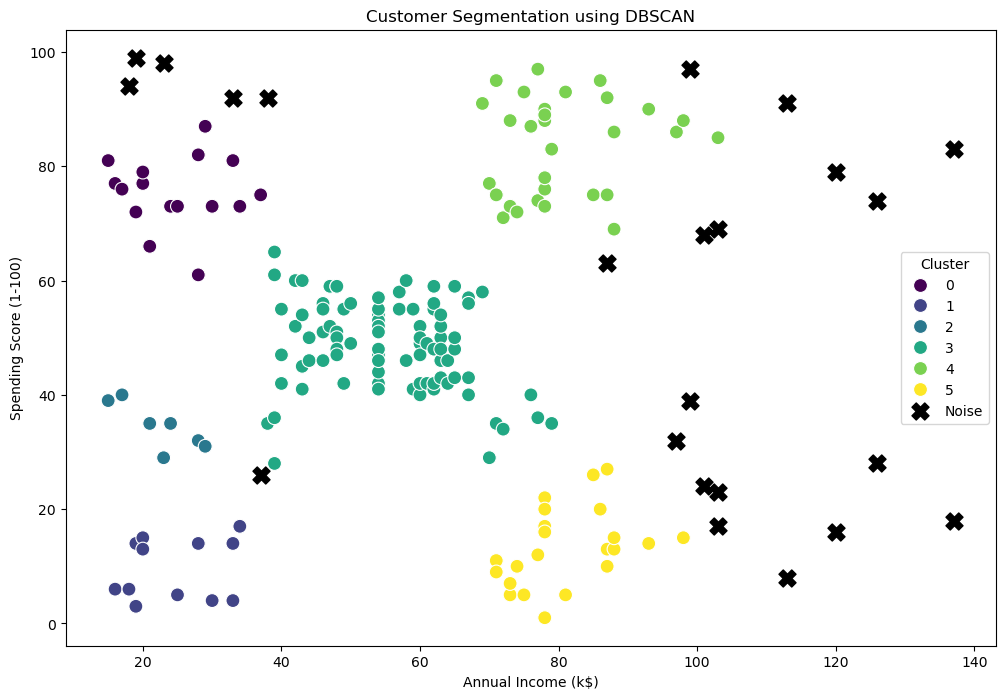

In [79]:
plt.figure(figsize=(12, 8))

non_noise_mask = dbscan_labels != -1

sns.scatterplot(
    x=X.loc[non_noise_mask, "Annual Income (k$)"],
    y=X.loc[non_noise_mask, "Spending Score (1-100)"],
    hue=dbscan_labels[non_noise_mask],
    palette="viridis",
    s=100
)

plt.scatter(
    X.loc[noise_mask, "Annual Income (k$)"],
    X.loc[noise_mask, "Spending Score (1-100)"],
    marker="X",
    s=150,
    color="black",
    label="Noise"
)

plt.title(
    "Customer Segmentation using DBSCAN"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.legend(title="Cluster")

plt.show()

In [81]:
non_noise_mask = dbscan_labels != -1

final_dbscan_score = silhouette_score(
    X_scaled[non_noise_mask],
    dbscan_labels[non_noise_mask]
)

print(
    "Final DBSCAN Silhouette Score:",
    round(final_dbscan_score, 4)
)

Final DBSCAN Silhouette Score: 0.5577


In [83]:
df_dbscan = df[
    df["DBSCAN_Cluster"] != -1
].copy()

In [85]:
dbscan_profile = df_dbscan.groupby(
    "DBSCAN_Cluster"
).agg(
    Customer_Count=("CustomerID", "count"),
    Average_Age=("Age", "mean"),
    Average_Income=("Annual Income (k$)", "mean"),
    Average_Spending=("Spending Score (1-100)", "mean")
).round(2)

dbscan_profile

,Customer_Count,Average_Age,Average_Income,Average_Spending
DBSCAN_Cluster,,,,
0,16,24.81,24.75,75.38
1,12,48.75,24.58,9.58
2,7,36.71,22.43,34.43
3,88,42.88,55.23,48.58
4,31,32.84,80.29,83.19
5,23,41.22,80.96,12.78


In [87]:
dbscan_profile.sort_values(
    "Average_Spending",
    ascending=False
)

,Customer_Count,Average_Age,Average_Income,Average_Spending
DBSCAN_Cluster,,,,
4,31,32.84,80.29,83.19
0,16,24.81,24.75,75.38
3,88,42.88,55.23,48.58
2,7,36.71,22.43,34.43
5,23,41.22,80.96,12.78
1,12,48.75,24.58,9.58


In [89]:
noise_customers = df[
    df["DBSCAN_Cluster"] == -1
].copy()

noise_customers[
    [
        "CustomerID",
        "Gender",
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
7,8,Female,23,18,94
11,12,Female,35,19,99
19,20,Female,35,23,98
33,34,Male,18,33,92
38,39,Female,36,37,26
41,42,Male,24,38,92
169,170,Male,32,87,63
180,181,Female,37,97,32
184,185,Female,41,99,39
185,186,Male,30,99,97


In [91]:
noise_customers[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
].mean().round(2)

Age                       34.43
Annual Income (k$)        89.26
Spending Score (1-100)    57.83
dtype: float64

In [93]:
algorithm_comparison = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical",
        "DBSCAN"
    ],
    "Silhouette_Score": [
        0.5547,
        0.5538,
        final_dbscan_score
    ]
})

algorithm_comparison

,Algorithm,Silhouette_Score
0,K-Means,0.554700
1,Hierarchical,0.553800
2,DBSCAN,0.557746


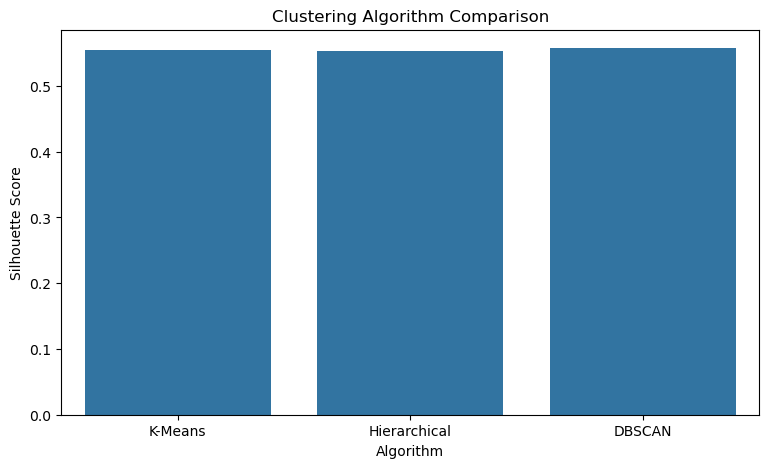

In [95]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=algorithm_comparison,
    x="Algorithm",
    y="Silhouette_Score"
)

plt.title(
    "Clustering Algorithm Comparison"
)

plt.ylabel("Silhouette Score")

plt.show()

In [97]:
df.to_csv(
    "outputs/results/dbscan_customer_segments.csv",
    index=False
)

dbscan_profile.to_csv(
    "outputs/results/dbscan_cluster_summary.csv"
)

dbscan_results_df.to_csv(
    "outputs/results/dbscan_parameter_search.csv",
    index=False
)

noise_customers.to_csv(
    "outputs/results/dbscan_noise_customers.csv",
    index=False
)

print("DBSCAN results saved successfully.")

DBSCAN results saved successfully.


In [99]:
import joblib

joblib.dump(
    final_dbscan,
    "models/dbscan_model.pkl"
)

joblib.dump(
    scaler,
    "models/dbscan_scaler.pkl"
)

print("DBSCAN model and scaler saved successfully.")

DBSCAN model and scaler saved successfully.


In [101]:
import os

files = [
    "outputs/results/dbscan_customer_segments.csv",
    "outputs/results/dbscan_cluster_summary.csv",
    "outputs/results/dbscan_parameter_search.csv",
    "outputs/results/dbscan_noise_customers.csv",
    "models/dbscan_model.pkl",
    "models/dbscan_scaler.pkl"
]

for file in files:
    print(
        file,
        "→",
        os.path.exists(file)
    )

outputs/results/dbscan_customer_segments.csv → True
outputs/results/dbscan_cluster_summary.csv → True
outputs/results/dbscan_parameter_search.csv → True
outputs/results/dbscan_noise_customers.csv → True
models/dbscan_model.pkl → True
models/dbscan_scaler.pkl → True
